<a href="https://colab.research.google.com/github/chalakafernando4/quantum-computing-tutorials/blob/main/08_Quantum_Machine_Learning/QSVM_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantum Machine Learning: Quantum Kernel Estimation (QSVM)

This notebook explores the intersection of Artificial Intelligence and Quantum Computing. We implement a Quantum Support Vector Machine (QSVM) to classify non-linear data, demonstrating how quantum feature spaces can provide a mathematical advantage over classical machine learning models.

## The Problem: Non-Linear Classification

In classical machine learning, a Support Vector Machine (SVM) tries to draw a straight line (or hyperplane) to separate different classes of data. If the data is highly entangled (like a circle of data points inside another circle), a straight line cannot separate them.

Classically, we use a "Kernel Trick" to project this data into higher dimensions where it *can* be separated by a flat plane. However, calculating these massive dimensional spaces classically becomes computationally expensive very quickly.

## The Quantum Solution: Hilbert Space

Quantum computers naturally operate in an exponentially large, complex math space called a **Hilbert Space**.

Instead of using classical math to project our data, we use a **Quantum Feature Map**. We take our classical data points ($x$) and encode them directly into the rotation angles of quantum bits, creating a quantum state:

$$|\psi(x)\rangle = U_{\Phi}(x)|0\rangle^{\otimes n}$$

Because the Hilbert space is so vast and complex, data that is hopelessly tangled in the classical 2D world becomes easily separable in the quantum realm. We use the quantum computer to calculate the inner products (the "distances") between these quantum states, and feed that matrix back to a classical SVM to draw the final boundary.

In the code below, we will:

1. Generate a complex, non-linear dataset (concentric circles).
2. Build a `ZZFeatureMap` to encode this data into a quantum circuit.
3. Train a hybrid Quantum-Classical SVM.
4. Plot the decision boundary to visually prove the quantum model learned to separate the data.

---



In [1]:
!pip install qiskit qiskit-aer matplotlib pylatexenc scikit-learn qiskit-machine-learning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 93.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 5.0 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=aaee22971527e693caba8bbd823b63e04376063fda245c5c23e104fcdf847b35
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


Initializing Quantum Machine Learning Pipeline...

Training Hybrid Quantum-Classical SVM...
Encoding classical data into quantum states (this may take a moment)...


/tmp/ipykernel_1925/2143766357.py:24: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=2, reps=2, entanglement='linear')



SUCCESS! QSVM Classification Accuracy: 100.00%



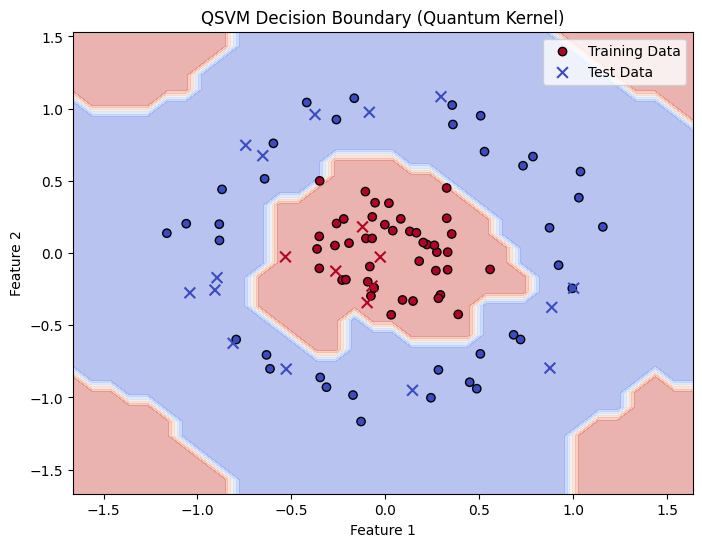


Quantum Feature Map Circuit (Data Encoding):


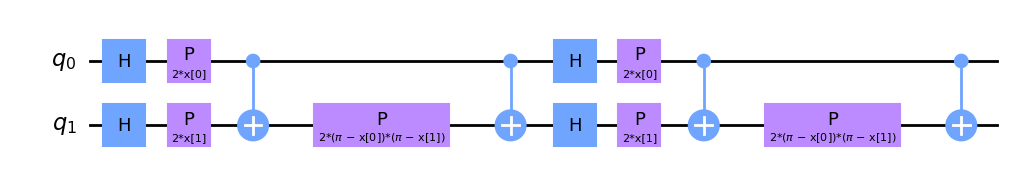

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel

def run_quantum_machine_learning():
    """Builds and trains a Quantum Support Vector Machine (QSVM)."""
    print("Initializing Quantum Machine Learning Pipeline...\n")

    # --- 1. Generate Non-Linear Classical Data ---
    # We create a dataset of circles within circles. A standard linear ML model would fail here.
    X, y = make_circles(n_samples=100, noise=0.1, factor=0.3, random_state=42)

    # Split into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # --- 2. The Quantum Feature Map ---
    # We use a ZZFeatureMap to encode our 2D classical data into a 2-qubit quantum state.
    # This maps the data into a high-dimensional Hilbert space.
    feature_map = ZZFeatureMap(feature_dimension=2, reps=2, entanglement='linear')

    # --- 3. Build the Quantum Kernel ---
    # The kernel evaluates the "distance" (fidelity) between data points in the quantum space.
    qkernel = FidelityQuantumKernel(feature_map=feature_map)

    # --- 4. Train the Hybrid Model ---
    print("Training Hybrid Quantum-Classical SVM...")
    print("Encoding classical data into quantum states (this may take a moment)...")

    # We pass the quantum kernel evaluation function into a standard scikit-learn SVM
    qsvm = SVC(kernel=qkernel.evaluate)
    qsvm.fit(X_train, y_train)

    # --- 5. Evaluate Accuracy ---
    score = qsvm.score(X_test, y_test)
    print(f"\nSUCCESS! QSVM Classification Accuracy: {score * 100:.2f}%\n")

    # --- 6. Visualization: Decision Boundary ---
    # Create a mesh grid to plot the boundaries the quantum model learned
    h = 0.1  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Predict the grid using the trained Quantum model
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = qsvm.predict(grid_points)
    Z = Z.reshape(xx.shape)

    # Plotting
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.coolwarm)
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors='k', cmap=plt.cm.coolwarm, label="Training Data")
    plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, marker='x', s=60, cmap=plt.cm.coolwarm, label="Test Data")
    plt.title("QSVM Decision Boundary (Quantum Kernel)")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.show()

    # Draw the Quantum Feature Map circuit
    print("\nQuantum Feature Map Circuit (Data Encoding):")
    display(feature_map.decompose().draw('mpl', style='clifford'))

# Execute the QML pipeline
run_quantum_machine_learning()